In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.datasets import fetch_california_housing
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

cal_housing = fetch_california_housing(as_frame=True)
X = cal_housing.data
y = cal_housing.target
print("数据集特征：", X.columns.tolist())
print("样本数：{}，特征数：{}".format(X.shape[0], X.shape[1]))

数据集特征： ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
样本数：20640，特征数：8


In [2]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print("训练样本数：{}，测试样本数：{}".format(X_train.shape[0], X_test.shape[0]))

训练样本数：14448，测试样本数：6192


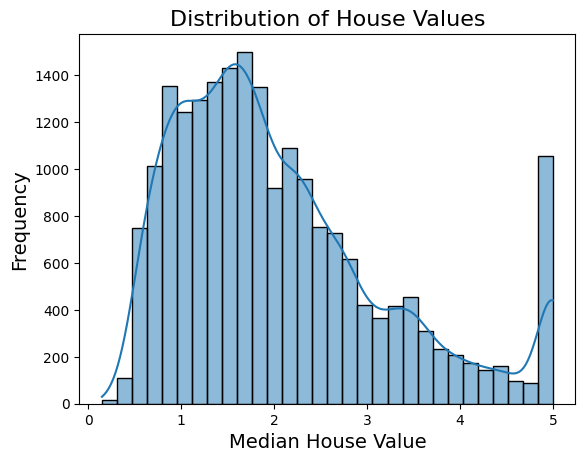

In [3]:
plt.figure()
sns.histplot(y, bins=30, color="#1f77b4", kde=True)
plt.xlabel("Median House Value", fontsize=14)
plt.ylabel("Frequency", fontsize=14)
plt.title("Distribution of House Values", fontsize=16)
plt.show()

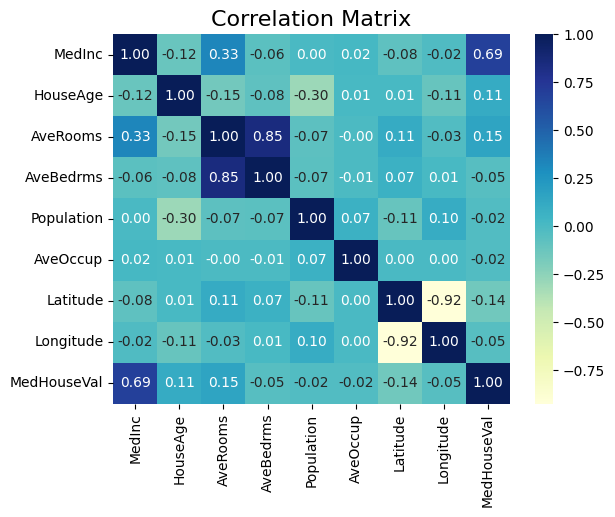

In [4]:
corr_matrix = pd.concat([X, y], axis=1).corr()
plt.figure()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Correlation Matrix", fontsize=16)
plt.show()

In [5]:
gbdt = GradientBoostingRegressor(random_state=42)
start_time = time.time()
gbdt.fit(X_train, y_train)
train_time = time.time() - start_time
print("初步模型训练时间: {:.3f} 秒".format(train_time))

初步模型训练时间: 1.647 秒


In [6]:
y_pred = gbdt.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n初步模型评估结果：")
print("Mean Squared Error (MSE): {:.4f}".format(mse))
print("Mean Absolute Error (MAE): {:.4f}".format(mae))
print("R^2 Score: {:.4f}".format(r2))


初步模型评估结果：
Mean Squared Error (MSE): 0.2884
Mean Absolute Error (MAE): 0.3714
R^2 Score: 0.7803


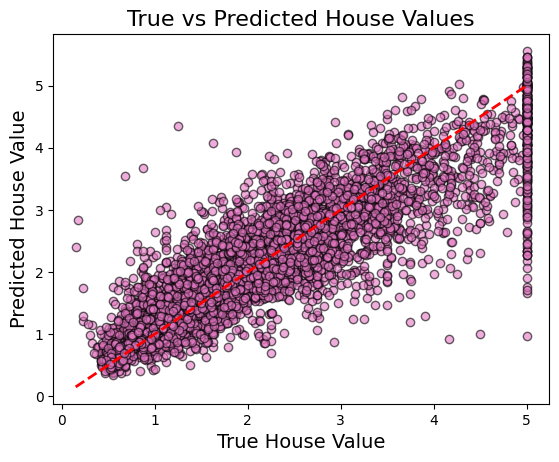

In [7]:
plt.figure()
plt.scatter(y_test, y_pred, alpha=0.6, color="#e377c2", edgecolor="k")
plt.xlabel("True House Value", fontsize=14)
plt.ylabel("Predicted House Value", fontsize=14)
plt.title("True vs Predicted House Values", fontsize=16)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2)
plt.show()

In [8]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.05, 0.1, 0.2],
    "max_depth": [3, 5, 7],
    "subsample": [0.8, 1.0]  # 引入 subsample 参数以防止过拟合，采用随机抽样
}

gbdt_opt = GradientBoostingRegressor(random_state=42)

grid_search = GridSearchCV(estimator=gbdt_opt,
                           param_grid=param_grid,
                           cv=5,
                           scoring="neg_mean_squared_error",
                           verbose=1)
grid_search.fit(X_train, y_train)

print("最佳参数：", grid_search.best_params_)
print("最佳得分 (MSE, negated): {:.4f}".format(grid_search.best_score_))

Fitting 5 folds for each of 54 candidates, totalling 270 fits
最佳参数： {'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 300, 'subsample': 0.8}
最佳得分 (MSE, negated): -0.2222


In [9]:
best_gbdt = grid_search.best_estimator_
start_time = time.time()
best_gbdt.fit(X_train, y_train)
opt_train_time = time.time() - start_time
print("优化后模型训练时间: {:.3f} 秒".format(opt_train_time))

优化后模型训练时间: 8.595 秒


In [10]:
y_opt_pred = best_gbdt.predict(X_test)
opt_mse = mean_squared_error(y_test, y_opt_pred)
opt_mae = mean_absolute_error(y_test, y_opt_pred)
opt_r2 = r2_score(y_test, y_opt_pred)

print("\n优化后模型评估结果：")
print("Mean Squared Error (MSE): {:.4f}".format(opt_mse))
print("Mean Absolute Error (MAE): {:.4f}".format(opt_mae))
print("R^2 Score: {:.4f}".format(opt_r2))


优化后模型评估结果：
Mean Squared Error (MSE): 0.2077
Mean Absolute Error (MAE): 0.2983
R^2 Score: 0.8417


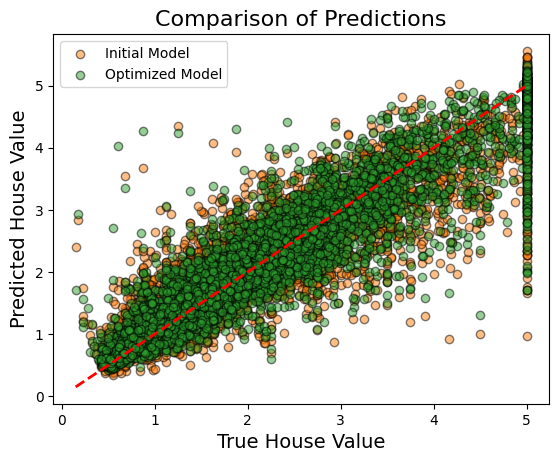

In [11]:
plt.figure()
plt.scatter(y_test, y_pred, alpha=0.5, color="#ff7f0e", label="Initial Model", edgecolor="k")
plt.scatter(y_test, y_opt_pred, alpha=0.5, color="#2ca02c", label="Optimized Model", edgecolor="k")
plt.xlabel("True House Value", fontsize=14)
plt.ylabel("Predicted House Value", fontsize=14)
plt.title("Comparison of Predictions", fontsize=16)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2)
plt.legend()
plt.show()

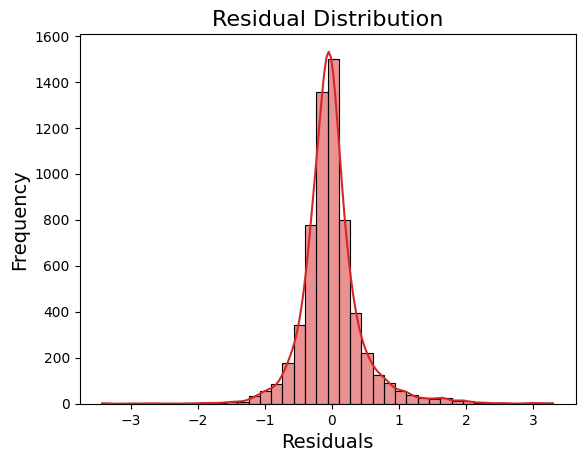

In [12]:
residuals = y_test - y_opt_pred

plt.figure()
sns.histplot(residuals, bins=40, kde=True, color="#d62728")
plt.xlabel("Residuals", fontsize=14)
plt.ylabel("Frequency", fontsize=14)
plt.title("Residual Distribution", fontsize=16)
plt.show()

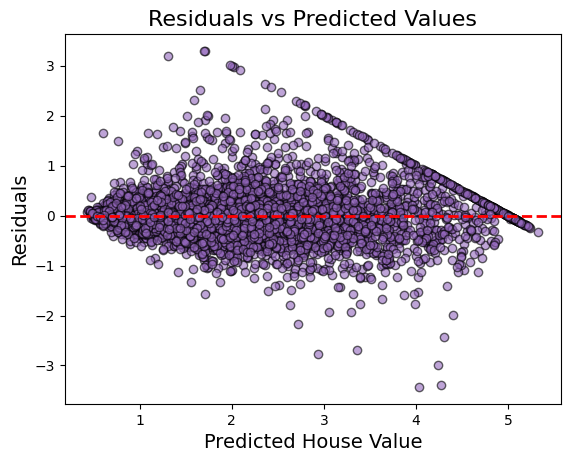

In [13]:
# 散点图展示残差与预测值的关系，判断是否存在系统性偏差
plt.figure()
plt.scatter(y_opt_pred, residuals, alpha=0.6, color="#9467bd", edgecolor="k")
plt.xlabel("Predicted House Value", fontsize=14)
plt.ylabel("Residuals", fontsize=14)
plt.title("Residuals vs Predicted Values", fontsize=16)
plt.axhline(y=0, color="r", linestyle="--", lw=2)
plt.show()

In [14]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, X, y, cv=5, train_sizes=np.linspace(0.1, 1.0, 10)):
    """
    绘制学习曲线函数
    参数：
        estimator: 模型
        X, y: 数据
        cv: 交叉验证折数
        train_sizes: 训练集比例
    """
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, train_sizes=train_sizes, scoring="neg_mean_squared_error", n_jobs=-1)

    # 均值与标准差
    train_scores_mean = -np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = -np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    plt.figure()
    plt.plot(train_sizes, train_scores_mean, "o-", color="#17becf", label="Training Error", lw=2)
    plt.plot(train_sizes, test_scores_mean, "o-", color="#bcbd22", label="Validation Error", lw=2)
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.15, color="#17becf")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.15, color="#bcbd22")
    plt.xlabel("Training Set Size", fontsize=14)
    plt.ylabel("Mean Squared Error", fontsize=14)
    plt.title("Learning Curve", fontsize=16)
    plt.legend()
    plt.show()

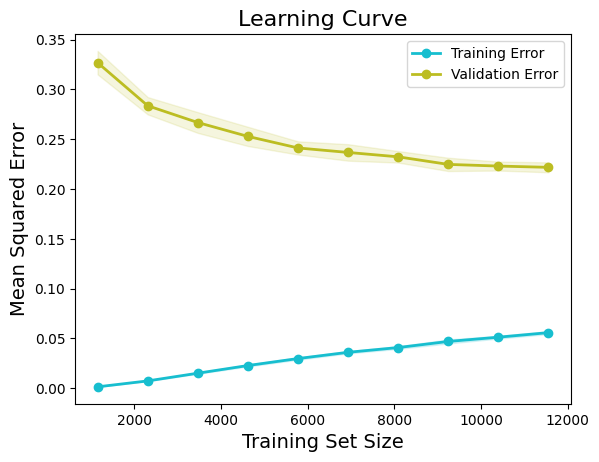

In [15]:
plot_learning_curve(best_gbdt, X_train, y_train, cv=5)

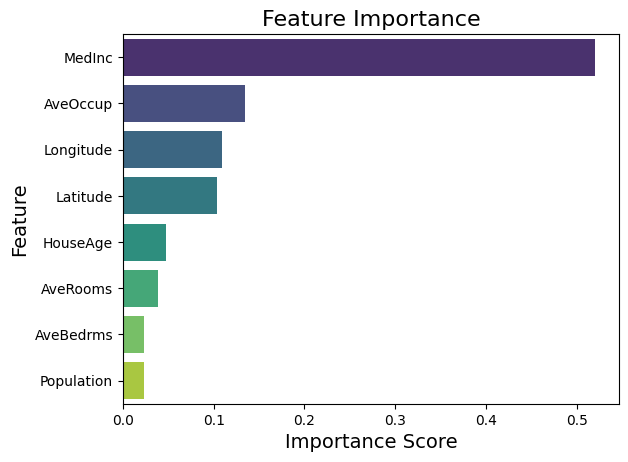

In [17]:
feature_importance = best_gbdt.feature_importances_
features = X.columns
fi_df = pd.DataFrame({"Feature": features, "Importance": feature_importance})
fi_df = fi_df.sort_values("Importance", ascending=False)

plt.figure()
sns.barplot(x="Importance", y="Feature", data=fi_df, hue="Feature", palette="viridis")
plt.xlabel("Importance Score", fontsize=14)
plt.ylabel("Feature", fontsize=14)
plt.title("Feature Importance", fontsize=16)
plt.show()

## 使用 GBDT 的优缺点

### 优点

- **高预测精度**：梯度提升决策树（GBDT）是一种强大的集成学习方法，能够通过逐步减少残差提升整体预测性能，在多数回归与分类任务中表现优异。

- **灵活性强**：可用于回归、分类、排序等任务，同时也允许灵活选择损失函数，如 MSE、Log Loss、Huber Loss 等。

- **自动特征选择能力**：决策树在构建过程中自动挑选出重要的特征，适用于特征维度高、特征之间关系复杂的情况。

- **可处理非线性关系**：GBDT 是非参数模型，能自然建模变量之间的非线性关系，无需对数据做复杂的特征变换。

- **较强的鲁棒性**：对于异常值和缺失值容忍度较高，尤其在原始数据质量不太好的时候仍可保持不错的性能。

### 缺点

- **训练速度慢，计算成本高**：尤其在数据集庞大或特征众多时，逐步迭代建模的方式会导致训练过程耗时较长。

- **模型解释性差**：相较于单一决策树，GBDT 是多个树的加权结果，难以直观解释每棵树的作用和单一预测路径。

- **容易过拟合**：尽管集成算法可以提升性能，但在参数调优不当时（如树太深、迭代次数太多）容易过拟合训练集。

- **对类别变量不友好（原始版本）**：需要对类别型变量进行 One-Hot 或 Label Encoding，会带来维度爆炸或信息丢失问题。